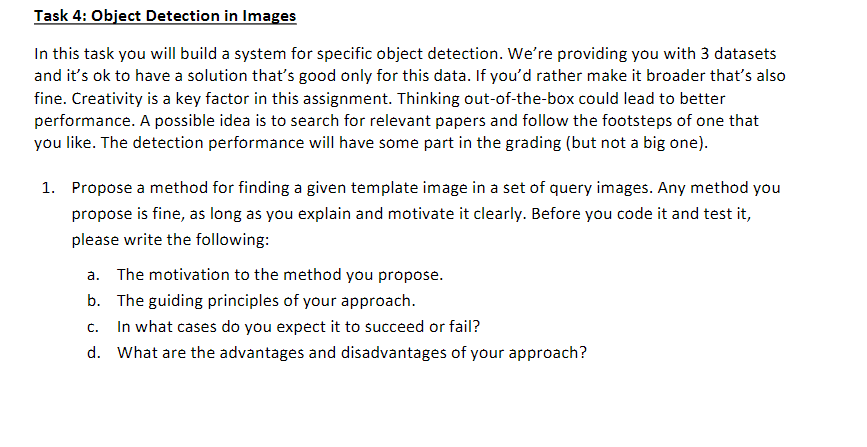

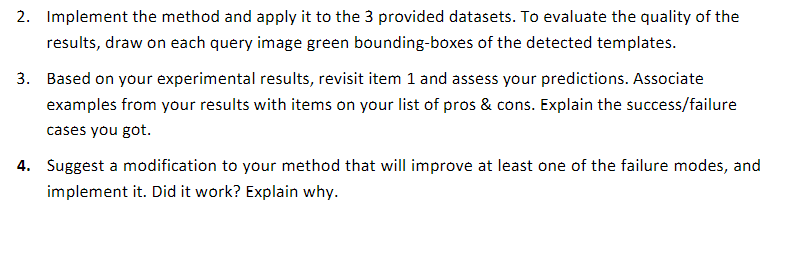

In [2]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt


: 

In [3]:
# Load a model
model = YOLO("yolov8n.yaml")  # build a new model from scratch
results = model.train(data='config.yaml', epochs=3)  # predict on an image


New https://pypi.org/project/ultralytics/8.2.61 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.60 🚀 Python-3.10.12 torch-2.3.1+cu121 CPU (AMD Ryzen 7 5700G with Radeon Graphics)
engine/trainer: task=detect, mode=train, model=yolov8n.yaml, data=config.yaml, epochs=3, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save

train: Scanning /home/ameer/Computer-Vesion/HW3/data1/labels/train.cache... 28 images, 0 backgrounds, 0 corrupt: 100%|██████████| 28/28 [00:00<?, ?it/s]
val: Scanning /home/ameer/Computer-Vesion/HW3/data1/labels/train.cache... 28 images, 0 backgrounds, 0 corrupt: 100%|██████████| 28/28 [00:00<?, ?it/s]


Plotting labels to /home/ameer/Computer-Vesion/runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /home/ameer/Computer-Vesion/runs/detect/train
Starting training for 3 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/3         0G      2.825      3.869      4.352         31        640: 100%|██████████| 2/2 [00:13<00:00,  6.86s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:05<00:00,  5.21s/it]

                   all         28         32    0.00274      0.719      0.013    0.00388



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/2 [00:00<?, ?it/s]


0: 480x640 (no detections), 101.8ms
Speed: 2.1ms preprocess, 101.8ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)
Detection results:


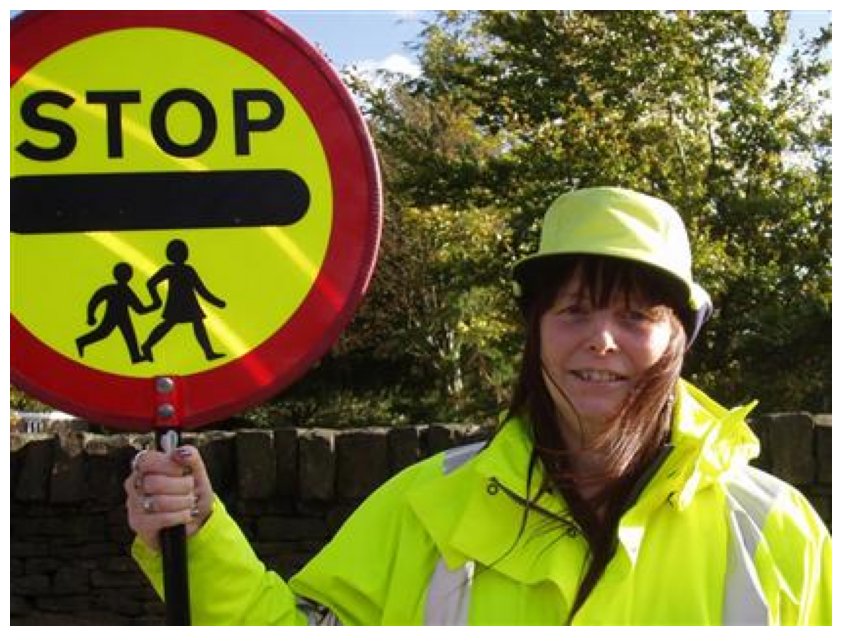

In [2]:
import os
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Define the paths
IMAGES_DIR = os.path.join('./Q4/', 'Roadsign')
IMAGE_PATH = os.path.join(IMAGES_DIR, 'image1.jpg')  # Replace with your image path
MODEL_PATH = os.path.join('../', 'runs', 'detect', 'train', 'weights', 'last.pt')  # Path to your custom model

# Load the YOLO model
model = YOLO(MODEL_PATH)  # Load a custom model

# Load and process the image
image = cv2.imread(IMAGE_PATH)
if image is None:
    raise FileNotFoundError(f"Image not found at {IMAGE_PATH}")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert image to RGB

# Perform object detection
results = model(image_rgb)[0]

# Debugging output
print("Detection results:")
for result in results.boxes.data.tolist():
    x1, y1, x2, y2, score, class_id = result
    print(f"Detected {results.names[int(class_id)]}: Score={score:.2f}, BBox=({x1}, {y1}, {x2}, {y2})")

# Draw bounding boxes and labels on the image
threshold = 0.3  # Lowered threshold
for result in results.boxes.data.tolist():
    x1, y1, x2, y2, score, class_id = result
    if score > threshold:
        # Draw bounding box
        cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 4)
        # Draw label
        label = results.names[int(class_id)].upper()
        cv2.putText(image, label, (int(x1), int(y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 255, 0), 3, cv2.LINE_AA)

# Display the result using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
